In [17]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction")  # root with train/, test/

train_dir = DATA_DIR / "train"
test_dir = DATA_DIR / "test"

In [18]:
def load_horizontal(well_id, split="train"):
    fn = DATA_DIR / split / f"{well_id}__horizontal_well.csv"
    df = pd.read_csv(fn)
    df["well_id"] = well_id
    df = df.sort_values("MD").reset_index(drop=True)
    return df

In [19]:
def load_typewell(well_id, split="train"):
    fn = DATA_DIR / split / f"{well_id}__typewell.csv"
    df = pd.read_csv(fn)
    df["well_id"] = well_id
    df = df.sort_values("TVT").reset_index(drop=True)
    return df

In [20]:
well_id = "000d7d20"
h = load_horizontal(well_id)
t = load_typewell(well_id)

h.info()
h.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5278 entries, 0 to 5277
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         5278 non-null   float64
 1   X          5278 non-null   float64
 2   Y          5278 non-null   float64
 3   Z          5278 non-null   float64
 4   ANCC       5278 non-null   float64
 5   ASTNU      5278 non-null   float64
 6   ASTNL      5278 non-null   float64
 7   EGFDU      5278 non-null   float64
 8   EGFDL      5278 non-null   float64
 9   BUDA       5278 non-null   float64
 10  TVT        5278 non-null   float64
 11  GR         3020 non-null   float64
 12  TVT_input  1442 non-null   float64
 13  well_id    5278 non-null   object 
dtypes: float64(13), object(1)
memory usage: 577.4+ KB


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
count,5278.000000,5.278000e+03,5.278000e+03,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,5278.000000,3020.000000,1442.000000
mean,14105.500000,2.983514e+06,1.071418e+06,-9673.194324,-9330.621821,-9504.671821,-9532.451821,-9605.801821,-9640.771821,-9781.161821,11715.831127,94.436961,11646.417864
std,1523.771691,2.997379e+01,1.503381e+03,80.961903,35.272977,35.272977,35.272977,35.272977,35.272977,35.272977,88.782092,18.627493,148.869554
min,11467.000000,2.983468e+06,1.069022e+06,-9755.610000,-9395.810000,-9569.860000,-9597.640000,-9670.990000,-9705.960000,-9846.350000,11236.020000,31.765827,11236.020000
25%,12786.250000,2.983487e+06,1.070090e+06,-9721.762500,-9362.307500,-9536.357500,-9564.137500,-9637.487500,-9672.457500,-9812.847500,11735.850000,85.068343,11566.195000
50%,14105.500000,2.983514e+06,1.071407e+06,-9689.230000,-9335.975000,-9510.025000,-9537.805000,-9611.155000,-9646.125000,-9786.515000,11742.130000,94.936506,11745.920000
75%,15424.750000,2.983535e+06,1.072723e+06,-9650.035000,-9296.665000,-9470.715000,-9498.495000,-9571.845000,-9606.815000,-9747.205000,11747.257500,103.960888,11747.465000
max,16744.000000,2.983578e+06,1.074041e+06,-9258.570000,-9271.000000,-9445.050000,-9472.830000,-9546.180000,-9581.150000,-9721.540000,11756.120000,217.352257,11756.120000


In [21]:
h[["TVT", "TVT_input", "GR"]].isna().sum()

TVT             0
TVT_input    3836
GR           2258
dtype: int64

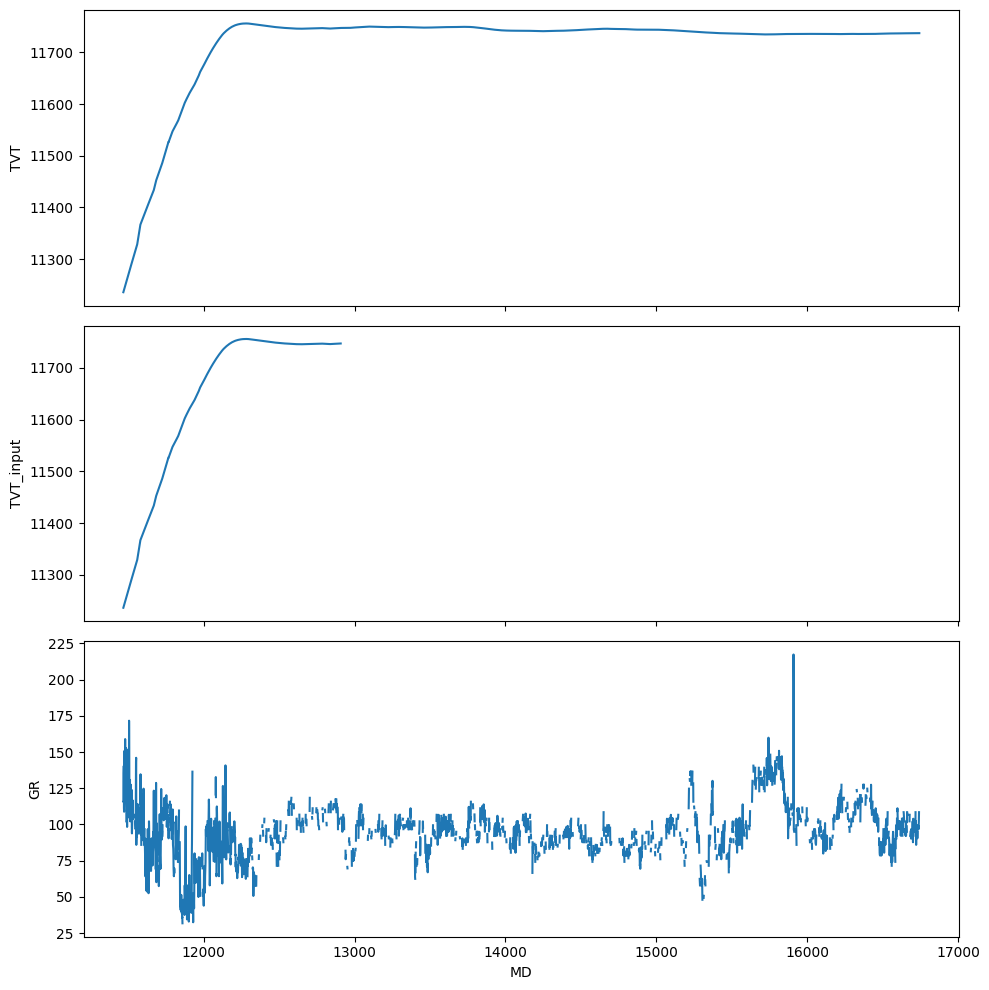

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(h["MD"], h["TVT"], label="TVT")
axes[0].set_ylabel("TVT")

axes[1].plot(h["MD"], h["TVT_input"], label="TVT_input")
axes[1].set_ylabel("TVT_input")

axes[2].plot(h["MD"], h["GR"], label="GR")
axes[2].set_ylabel("GR")
axes[2].set_xlabel("MD")

plt.tight_layout()

In [23]:
def list_well(split="train"):
    files = sorted((DATA_DIR / split).glob("*__horizontal_well.csv"))
    return [f.name.split("__")[0] for f in files]

train_wells = list_well("train")
test_wells = list_well("test")

In [24]:
summary = []
for w in train_wells:
    h = load_horizontal(w, "train")
    summary.append({
        "well_id": w,
        "n_rows": len(h),
        "gr_missing_frac": h["GR"].isna().mean(),
        "tvt_input_missing_frac": h["TVT_input"].isna().mean(),
        "md_min": h["MD"].min(),
        "md_max": h["MD"].max(),
        "tvt_min": h["TVT"].min(),
        "tvt_max": h["TVT"].max(),
    })

summary_df = pd.DataFrame(summary)

In [25]:
summary_df.head()

,well_id,n_rows,gr_missing_frac,tvt_input_missing_frac,md_min,md_max,tvt_min,tvt_max
0,000d7d20,5278,0.427814,0.726790,11467.0,16744.0,11236.02,11756.12
1,00bbac68,7559,0.124620,0.795608,11578.0,19136.0,11406.63,12240.01
2,00e12e8b,6384,0.091479,0.673716,10456.0,16839.0,10606.18,11616.64
3,015fe0d2,5950,0.254286,0.722017,11834.0,17783.0,11747.26,12271.53
4,01869cd4,6850,0.477080,0.811241,11256.0,18105.0,11358.27,11767.75


In [26]:
from sklearn.metrics import mean_squared_error

In [29]:
def baseline_tvt_prediction(h_df: pd.DataFrame) -> pd.Series:
    df = h_df.sort_values("MD").reset_index(drop=True)
    pred = df["TVT_input"].copy()
    known_mask = ~pred.isna()

    if known_mask < 2:
        return df["TVT"].copy

    # Interpolater over MD using only known points
    md_known = df.loc[known_mask, "MD"].values
    tvt_known = df.loc[known_mask, "TVT_input"].values
    md_all = df["MD"].values

    interp_all = np.interp(md_all, md_known, tvt_known)

    pred[~known_mask] = interp_all[~known_mask]
    return pred